In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\bette\OneDrive\Desktop\netflix_churn_clean.csv')

df.shape

(4999, 13)

In [8]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,43.846369,8.015929,30.090418,13.683339,0.503101,3.024405
std,15.502507,6.229190,17.537778,3.692429,0.500040,1.415983
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000
25%,30.000000,2.840000,15.000000,8.990000,0.000000,2.000000
50%,44.000000,6.560000,30.000000,13.990000,1.000000,3.000000
75%,58.000000,12.115000,45.000000,17.990000,1.000000,4.000000
max,70.000000,23.970000,60.000000,17.990000,1.000000,5.000000


In [10]:
# overall churn rate as a percentage
print(f"Overall churn rate: {df['churned'].mean()*100:.1f}%")

# churn rate broken down by plan
df.groupby('subscription_type')['churned'].mean()

Overall churn rate: 50.3%


subscription_type
Basic       0.618302
Premium     0.437094
Standard    0.454711
Name: churned, dtype: float64

In [12]:
print("Churn by region:")
print(df.groupby('region')['churned'].mean().sort_values(ascending=False))

print("\nChurn by device:")
print(df.groupby('device')['churned'].mean().sort_values(ascending=False))

Churn by region:
region
Europe           0.516724
South America    0.514318
Asia             0.507143
Oceania          0.500654
North America    0.494712
Africa           0.483188
Name: churned, dtype: float64

Churn by device:
device
Laptop     0.517893
Mobile     0.504980
TV         0.500000
Tablet     0.500000
Desktop    0.492097
Name: churned, dtype: float64


In [18]:
# average watch_hours and last_login_days, split by churned vs not
df.groupby('churned')[['watch_hours', 'last_login_days', 'age', 'number_of_profiles']].mean()

,watch_hours,last_login_days,age,number_of_profiles
churned,,,,
0,10.274803,21.768921,43.900161,3.250403
1,5.784899,38.309344,43.793241,2.801193


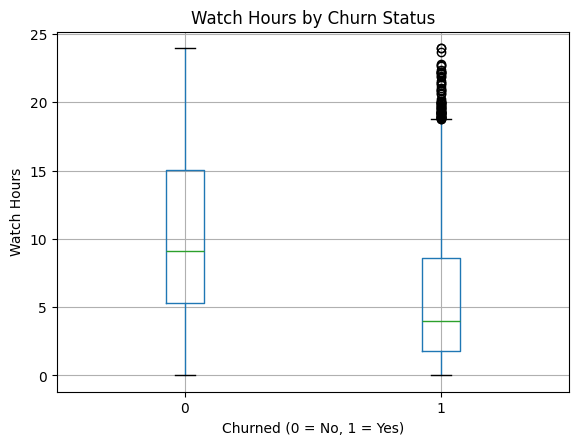

In [22]:
import matplotlib.pyplot as plt

df.boxplot(column='watch_hours', by='churned')
plt.title('Watch Hours by Churn Status')
plt.suptitle('')  
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Watch Hours')
plt.show()

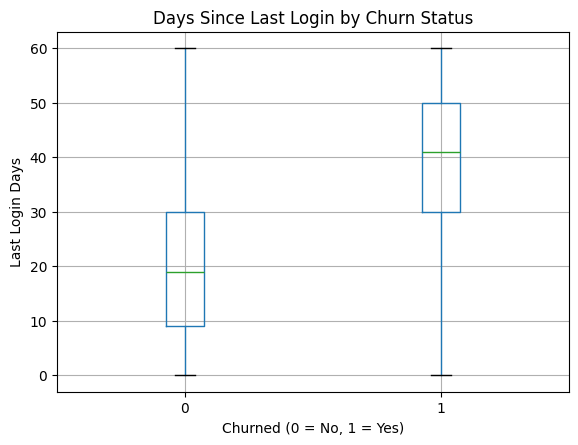

In [24]:
df.boxplot(column='last_login_days', by='churned')
plt.title('Days Since Last Login by Churn Status')
plt.suptitle('')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Last Login Days')
plt.show()

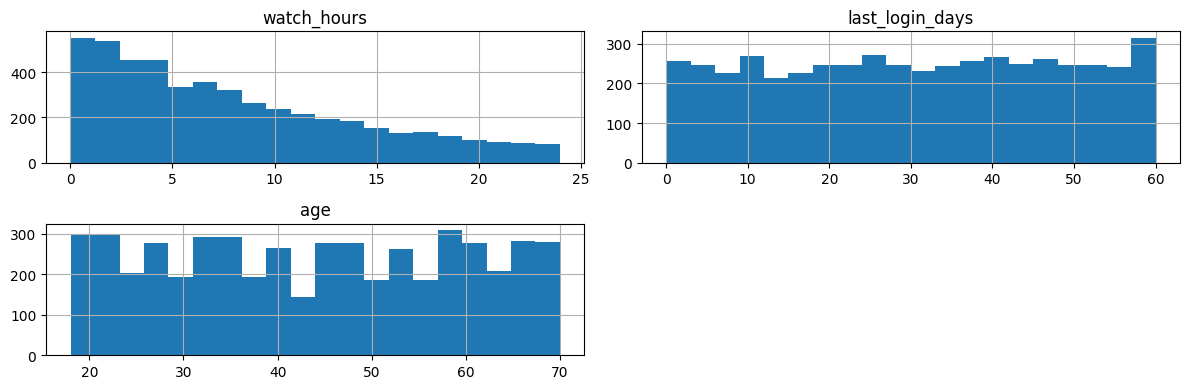

In [26]:
df[['watch_hours', 'last_login_days', 'age']].hist(figsize=(12, 4), bins=20)
plt.tight_layout()
plt.show()

In [28]:
df[['watch_hours', 'last_login_days', 'age', 'monthly_fee', 'number_of_profiles', 'churned']].corr()

,watch_hours,last_login_days,age,monthly_fee,number_of_profiles,churned
watch_hours,1.000000,0.018216,0.009152,0.012680,-0.022302,-0.360421
last_login_days,0.018216,1.000000,0.016781,-0.000786,0.017242,0.471604
age,0.009152,0.016781,1.000000,-0.013948,0.017334,-0.003449
monthly_fee,0.012680,-0.000786,-0.013948,1.000000,0.021905,-0.152116
number_of_profiles,-0.022302,0.017242,0.017334,0.021905,1.000000,-0.158634
churned,-0.360421,0.471604,-0.003449,-0.152116,-0.158634,1.000000
